In [159]:
import matplotlib.pyplot as plt
import pandas as pd
import math, numpy as np
import re
import seaborn as sns

In [160]:
time_cache = '../data/outs/0327/all_time_cache.csv'
mem = '../data/outs/0327/all_mem.csv'

try:
    df_tcache = pd.read_csv(time_cache, sep=' ')
    df_mem = pd.read_csv(mem, sep=' ')
    print("Dados lidos com sucesso!")

except FileNotFoundError:
    print(f"Erro: Arquivo não encontrado!")

Dados lidos com sucesso!


In [161]:
df_tcache.dtypes

nome           object
n               int64
m               int64
c               int64
insert          int64
extractMin      int64
dk              int64
bkmp            int64
fila           object
cpu_time        int64
wall_time       int64
l1_miss         int64
l2_ref          int64
llc_miss        int64
cycles          int64
inst            int64
dtlb            int64
page_faults     int64
branch_inst     int64
branch_miss     int64
dtype: object

In [162]:
df_mem.dtypes

nome    object
n        int64
m        int64
c        int64
fila    object
mem      int64
dtype: object

In [163]:
# selecionar todos que não são MEM

df_tcache = df_tcache[df_tcache["nome"].str.startswith("MEM")]
df_mem = df_mem[df_mem["nome"].str.startswith("MEM")]

# Uso de memória

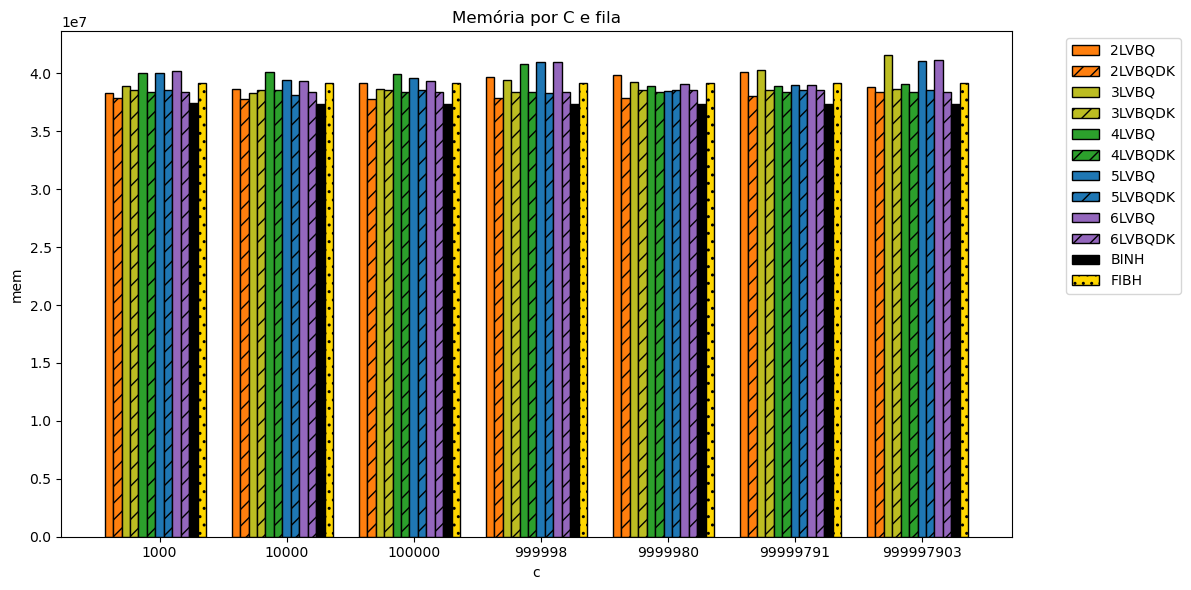

In [164]:
pivot = df_mem.pivot_table(
    index="c",
    columns="fila",
    values="mem",
    aggfunc="first"
)

c_vals = pivot.index.to_list()
filas = pivot.columns.to_list()

x = np.arange(len(c_vals))
width = 0.8 / len(filas)

# 🎨 cores por número da fila (LVBQ)
colors = {
    "1": "tab:red",
    "2": "tab:orange",
    "3": "tab:olive",
    "4": "tab:green",
    "5": "tab:blue",
    "6": "tab:purple",
}

plt.figure(figsize=(12, 6))

for i, fila in enumerate(filas):

    # ===== HEAPS (cores exclusivas) =====
    if "BINH" in fila:
        color = "black"
        hatch = "xx"
        
    elif "FIBH" in fila:
        color = "gold"
        hatch = ".."

    # ===== LVBQ / LVBQDK =====
    else:
        # extrai número da fila (1–6)
        m = re.match(r"\d+", fila)
        num = m.group() if m else None

        color = colors.get(num, "tab:gray")

        # padrão para DK
        hatch = "//" if "LVBQDK" in fila else None

    plt.bar(
        x + i * width,
        pivot[fila].values,
        width,
        label=fila,
        color=color,
        hatch=hatch,
        edgecolor="black"
    )

plt.xticks(x + width * len(filas) / 2, c_vals)
plt.xlabel("c")
plt.ylabel("mem")
plt.title("Memória por C e fila")
plt.legend(bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()

In [165]:
rank = (
    df_mem
    .sort_values(['nome', 'mem'])
    .groupby('nome')
    .head(6)
)

rank['rank'] = rank.groupby('nome').cumcount() + 1

resultado = rank.pivot(
    index='nome',
    columns='rank',
    values=['fila', 'mem']
)

resultado.columns = [f'{col}{rank}' for col, rank in resultado.columns]

resultado = resultado.reset_index()

resultado = resultado.sort_values('mem1')

resultado

,nome,fila1,fila2,fila3,fila4,fila5,fila6,mem1,mem2,mem3,mem4,mem5,mem6
1,MEM4,BINH,2LVBQDK,5LVBQDK,3LVBQ,6LVBQDK,3LVBQDK,37355520,37748736,38141952,38268928,38404096,38535168
2,MEM5,BINH,2LVBQDK,4LVBQDK,6LVBQDK,3LVBQDK,5LVBQDK,37355520,37748736,38404096,38404096,38535168,38535168
3,MEM6,BINH,2LVBQDK,5LVBQDK,3LVBQDK,4LVBQDK,6LVBQDK,37355520,37879808,38273024,38404096,38404096,38404096
4,MEM7,BINH,2LVBQDK,4LVBQDK,5LVBQ,3LVBQDK,5LVBQDK,37355520,37879808,38404096,38457344,38535168,38535168
5,MEM8,BINH,2LVBQDK,4LVBQDK,3LVBQDK,5LVBQDK,6LVBQDK,37355520,38010880,38404096,38535168,38535168,38535168
6,MEM9,BINH,2LVBQDK,4LVBQDK,6LVBQDK,5LVBQDK,3LVBQDK,37355520,38404096,38404096,38404096,38535168,38666240
0,MEM3,BINH,2LVBQDK,2LVBQ,4LVBQDK,6LVBQDK,3LVBQDK,37486592,37879808,38273024,38404096,38404096,38535168


# Tempo de execução

In [166]:
df_tcache.head()

,nome,n,m,c,insert,extractMin,dk,bkmp,fila,cpu_time,wall_time,l1_miss,l2_ref,llc_miss,cycles,inst,dtlb,page_faults,branch_inst,branch_miss
0,MEM3,100000,500000,1000,144604,144604,0,1978,1LVBQ,34,34,2053886,2575683,86684,146735355,268450551,105278,1066,39023205,249005
1,MEM3,100000,500000,1000,144929,144929,0,1921,1LVBQ,34,34,2065011,2577485,105017,150483151,269203503,103679,0,39189441,245328
2,MEM3,100000,500000,1000,144817,144817,0,1651,1LVBQ,34,34,2065453,2581783,95189,147721831,269149150,105209,536,39172767,248122
3,MEM3,100000,500000,1000,144876,144876,0,1707,1LVBQ,32,32,2064485,2583790,82578,143982845,269111268,103636,0,39181485,246413
4,MEM3,100000,500000,1000,145087,145087,0,2358,1LVBQ,32,32,2076957,2593165,84045,144424498,269375320,109200,0,39216812,245502


In [167]:
df_time = df_tcache[
    ['nome', 'n', 'c', 'fila', 'cpu_time', 'wall_time']
].copy()
df_time

,nome,n,c,fila,cpu_time,wall_time
0,MEM3,100000,1000,1LVBQ,34,34
1,MEM3,100000,1000,1LVBQ,34,34
2,MEM3,100000,1000,1LVBQ,34,34
3,MEM3,100000,1000,1LVBQ,32,32
4,MEM3,100000,1000,1LVBQ,32,32
...,...,...,...,...,...,...
835,MEM8,100000,99999791,FIBH,105,105
836,MEM8,100000,99999791,FIBH,104,104
837,MEM8,100000,99999791,FIBH,105,105
838,MEM8,100000,99999791,FIBH,105,105


In [168]:
df_time["wall_cpu_ratio"] = df_time["wall_time"] / df_time["cpu_time"]
print("Min ratio", df_time["wall_cpu_ratio"].min())
print("Max ratio", df_time["wall_cpu_ratio"].max())

Min ratio 1.0
Max ratio 1.0256410256410255


Logo, CPU Bound

In [169]:
df_cpu = df_tcache[
    ['nome', 'n', 'c', 'fila', 'cpu_time']
].copy()
df_cpu = (
    df_cpu.groupby(['nome', 'fila'], as_index=False)
      .agg(
           cpu_mean=('cpu_time', 'mean'),
           cpu_std =('cpu_time', 'std'),
           cpu_var =('cpu_time', 'var'),
           c=('c', 'first'),
      )
)
df_cpu['cpu_cv'] = df_cpu['cpu_std'] / df_cpu['cpu_mean']
df_cpu

,nome,fila,cpu_mean,cpu_std,cpu_var,c,cpu_cv
0,MEM3,1LVBQ,32.9,0.994429,0.988889,1000,0.030226
1,MEM3,1LVBQDK,29.9,0.316228,0.100000,1000,0.010576
2,MEM3,2LVBQ,34.5,0.971825,0.944444,1000,0.028169
3,MEM3,2LVBQDK,33.5,0.527046,0.277778,1000,0.015733
4,MEM3,3LVBQ,40.6,0.699206,0.488889,1000,0.017222
...,...,...,...,...,...,...,...
79,MEM8,5LVBQDK,50.1,0.316228,0.100000,99999791,0.006312
80,MEM8,6LVBQ,85.6,0.516398,0.266667,99999791,0.006033
81,MEM8,6LVBQDK,53.6,0.516398,0.266667,99999791,0.009634
82,MEM8,BINH,84.2,0.421637,0.177778,99999791,0.005008


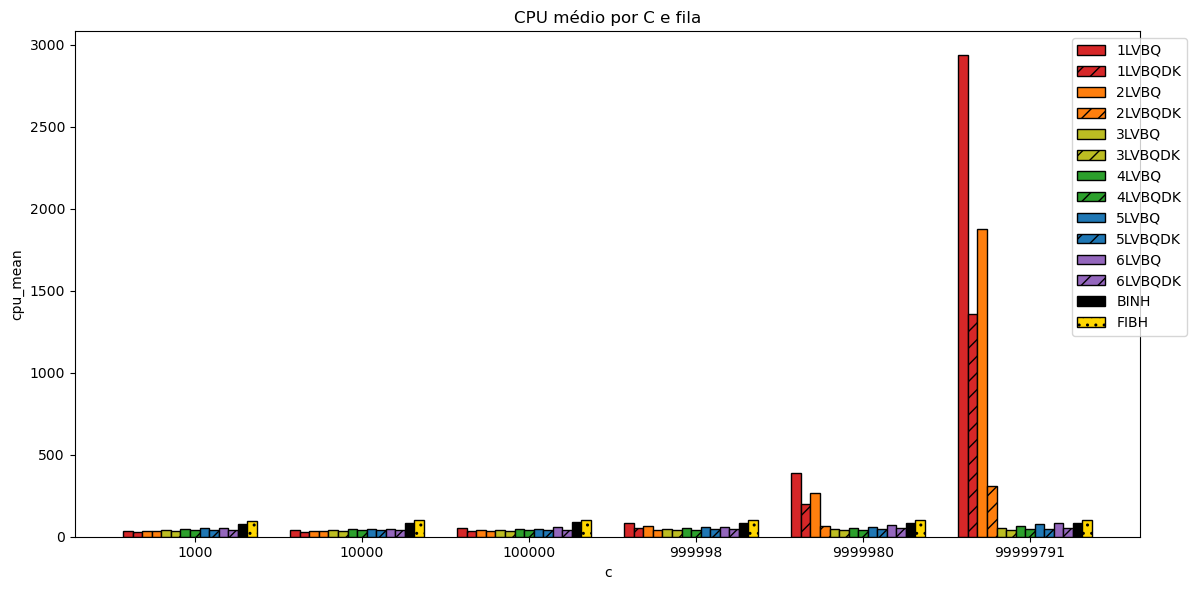

In [170]:
pivot = df_cpu.pivot_table(
    index="c",
    columns="fila",
    values="cpu_mean",
    aggfunc="first"
)

n_vals = pivot.index.to_list()
filas = pivot.columns.to_list()

x = np.arange(len(n_vals))
width = 0.8 / len(filas)

# 🎨 cores por número da fila (LVBQ)
colors = {
    "1": "tab:red",
    "2": "tab:orange",
    "3": "tab:olive",
    "4": "tab:green",
    "5": "tab:blue",
    "6": "tab:purple",
}

plt.figure(figsize=(12, 6))

for i, fila in enumerate(filas):

    # ===== HEAPS (se existirem) =====
    if "BINH" in fila:
        color = "black"
        hatch = "xx"
        
    elif "FIBH" in fila:
        color = "gold"
        hatch = ".."

    # ===== LVBQ / LVBQDK =====
    else:
        m = re.match(r"\d+", fila)
        num = m.group() if m else None

        color = colors.get(num, "tab:gray")

        # DK com padrão
        hatch = "//" if "LVBQDK" in fila else None

    plt.bar(
        x + i * width,
        pivot[fila].values,
        width,
        label=fila,
        color=color,
        hatch=hatch,
        edgecolor="black"
    )

plt.xticks(x + width * len(filas) / 2, n_vals)
plt.xlabel("c")
plt.ylabel("cpu_mean")
plt.title("CPU médio por C e fila")
plt.legend(bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()

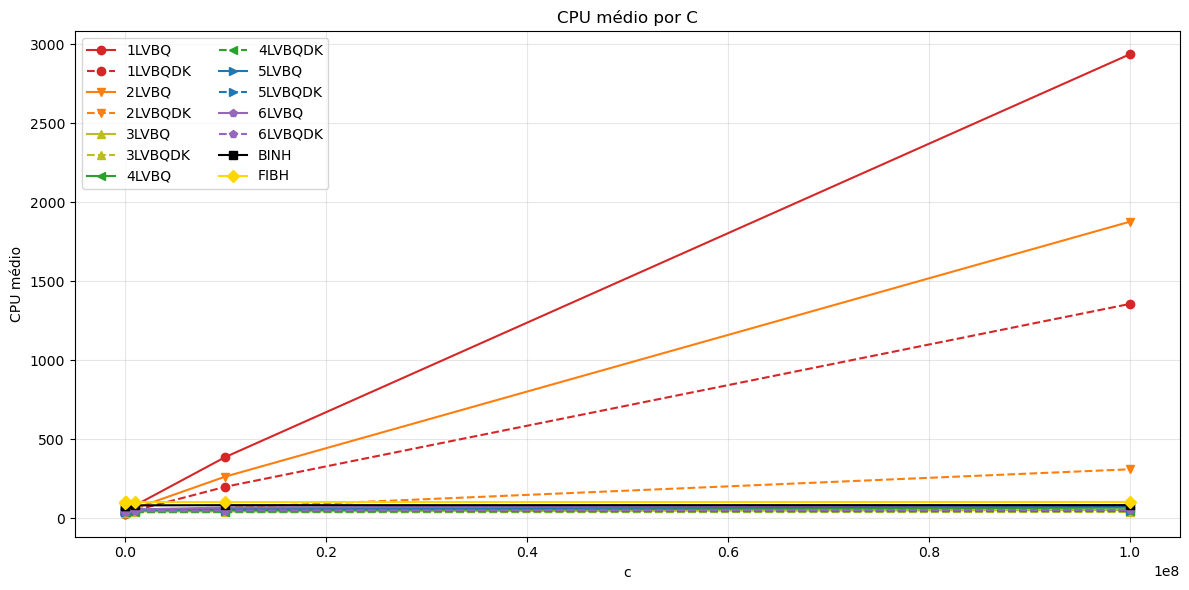

In [171]:

# selecionar BINH, Fibonacci e todas LVBQ (1–6) com ou sem DK
mask = (
    (df_cpu["fila"] == "BINH") |
    (df_cpu["fila"] == "FIBH") |  # adiciona Fibonacci
    (df_cpu["fila"].str.match(r"[1-6]LVBQ(DK)?"))
)

df_sel = df_cpu[mask].copy()

# ordenar por n (ESSENCIAL para gráfico de linhas)
df_sel = df_sel.sort_values("c")

# ordem consistente das curvas
filas_sel = sorted(df_sel["fila"].unique())

# 🔹 marcadores por nível LVBQ
marcadores_nivel = {
    1: "o",   # círculo
    2: "v",   # triângulo para baixo
    3: "^",   # triângulo para cima
    4: "<",   # triângulo para esquerda
    5: ">",   # triângulo para direita
    6: "p",   # pentágono
}

plt.figure(figsize=(12, 6))

for fila in filas_sel:
    dados = df_sel[df_sel["fila"] == fila]

    if dados.empty:
        continue

    # ===== BINH =====
    if fila == "BINH":
        color = "black"
        linestyle = "-"
        marker = "s"

    # ===== FIBH (Fibonacci) =====
    elif fila == "FIBH":
        color = "gold"
        linestyle = "-"
        marker = "D"  # diamante

    # ===== LVBQ / LVBQDK =====
    else:
        nivel = int(re.match(r"\d+", fila).group())

        # 🎨 cor por nível (1–6)
        cores = {
            1: "tab:red",
            2: "tab:orange",
            3: "tab:olive",
            4: "tab:green",
            5: "tab:blue",
            6: "tab:purple",
        }
        color = cores[nivel]

        # DK → tracejado
        linestyle = "--" if "DK" in fila else "-"

        # marcador por nível
        marker = marcadores_nivel[nivel]

    plt.plot(
        dados["c"],
        dados["cpu_mean"],
        label=fila,
        color=color,
        linestyle=linestyle,
        marker=marker
    )

plt.xlabel("c")
plt.ylabel("CPU médio")
plt.title("CPU médio por C")
plt.legend(ncol=2)  # legenda mais compacta
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

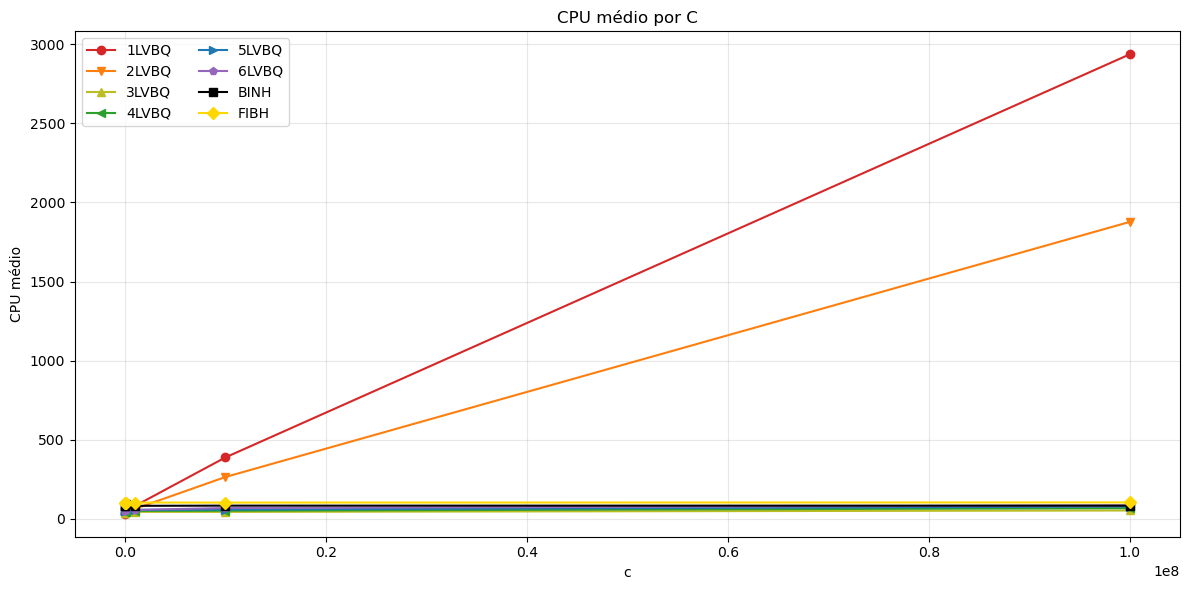

In [172]:
# 🎯 selecionar BINH, Fibonacci e todas LVBQ (1–6) **sem DK**
mask = (
    (df_cpu["fila"] == "BINH") |
    (df_cpu["fila"] == "FIBH") |  # adiciona Fibonacci
    (df_cpu["fila"].str.match(r"[1-6]LVBQ$"))  # somente LVBQ sem DK
)

df_sel = df_cpu[mask].copy()

# ordenar por n (ESSENCIAL para gráfico de linhas)
df_sel = df_sel.sort_values("c")

# ordem consistente das curvas
filas_sel = sorted(df_sel["fila"].unique())

# 🔹 marcadores por nível LVBQ
marcadores_nivel = {
    1: "o",   # círculo
    2: "v",   # triângulo para baixo
    3: "^",   # triângulo para cima
    4: "<",   # triângulo para esquerda
    5: ">",   # triângulo para direita
    6: "p",   # pentágono
}

plt.figure(figsize=(12, 6))

for fila in filas_sel:
    dados = df_sel[df_sel["fila"] == fila]

    if dados.empty:
        continue

    # ===== BINH =====
    if fila == "BINH":
        color = "black"
        linestyle = "-"
        marker = "s"

    # ===== FIBH (Fibonacci) =====
    elif fila == "FIBH":
        color = "gold"
        linestyle = "-"
        marker = "D"  # diamante

    # ===== LVBQ simples (1–6) =====
    else:
        nivel = int(re.match(r"\d+", fila).group())

        # 🎨 cor por nível (1–6)
        cores = {
            1: "tab:red",
            2: "tab:orange",
            3: "tab:olive",
            4: "tab:green",
            5: "tab:blue",
            6: "tab:purple",
        }
        color = cores[nivel]

        linestyle = "-"  # todas LVBQ simples são sólidas
        marker = marcadores_nivel[nivel]

    plt.plot(
        dados["c"],
        dados["cpu_mean"],
        label=fila,
        color=color,
        linestyle=linestyle,
        marker=marker
    )

plt.xlabel("c")
plt.ylabel("CPU médio")
plt.title("CPU médio por C")
plt.legend(ncol=2)  # legenda mais compacta
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

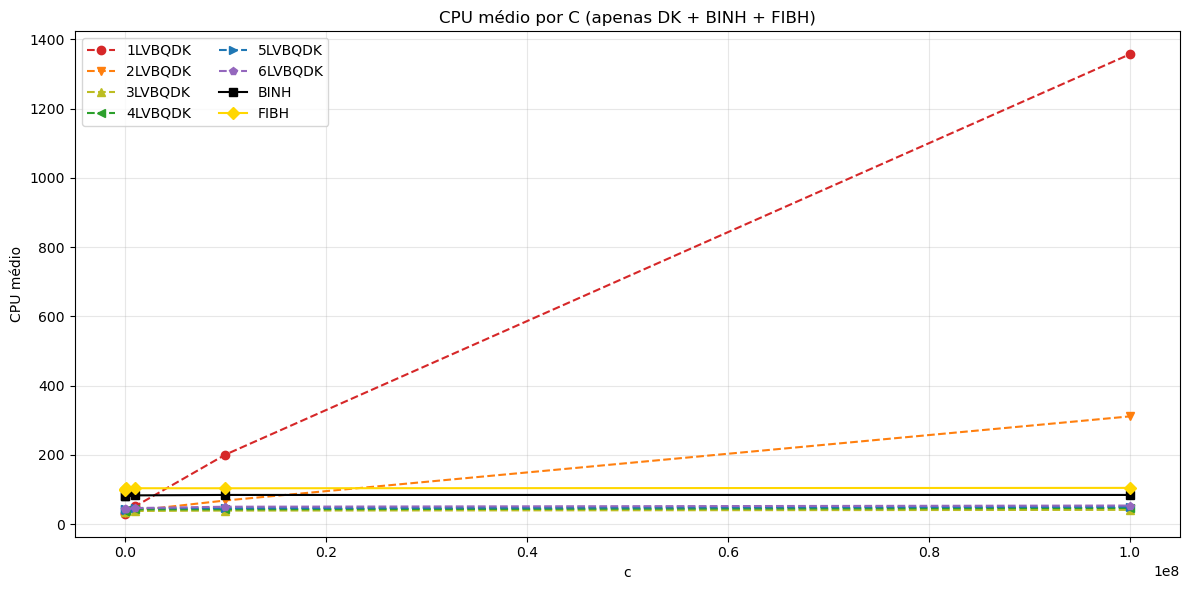

In [173]:
# 🎯 selecionar BINH, Fibonacci e todas LVBQ (1–6) **apenas DK**
mask = (
    (df_cpu["fila"] == "BINH") |
    (df_cpu["fila"] == "FIBH") |  # adiciona Fibonacci
    (df_cpu["fila"].str.match(r"[1-6]LVBQDK$"))  # somente LVBQ DK
)

df_sel = df_cpu[mask].copy()

# ordenar por n (ESSENCIAL para gráfico de linhas)
df_sel = df_sel.sort_values("c")

# ordem consistente das curvas
filas_sel = sorted(df_sel["fila"].unique())

# 🔹 marcadores por nível LVBQ
marcadores_nivel = {
    1: "o",   # círculo
    2: "v",   # triângulo para baixo
    3: "^",   # triângulo para cima
    4: "<",   # triângulo para esquerda
    5: ">",   # triângulo para direita
    6: "p",   # pentágono
}

plt.figure(figsize=(12, 6))

for fila in filas_sel:
    dados = df_sel[df_sel["fila"] == fila]

    if dados.empty:
        continue

    # ===== BINH =====
    if fila == "BINH":
        color = "black"
        linestyle = "-"
        marker = "s"

    # ===== FIBH (Fibonacci) =====
    elif fila == "FIBH":
        color = "gold"
        linestyle = "-"
        marker = "D"  # diamante

    # ===== LVBQ DK (1–6) =====
    else:
        nivel = int(re.match(r"\d+", fila).group())

        # 🎨 cor por nível (1–6)
        cores = {
            1: "tab:red",
            2: "tab:orange",
            3: "tab:olive",
            4: "tab:green",
            5: "tab:blue",
            6: "tab:purple",
        }
        color = cores[nivel]

        linestyle = "--"  # DK → tracejado
        marker = marcadores_nivel[nivel]

    plt.plot(
        dados["c"],
        dados["cpu_mean"],
        label=fila,
        color=color,
        linestyle=linestyle,
        marker=marker
    )

plt.xlabel("c")
plt.ylabel("CPU médio")
plt.title("CPU médio por C (apenas DK + BINH + FIBH)")
plt.legend(ncol=2)  # legenda mais compacta
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

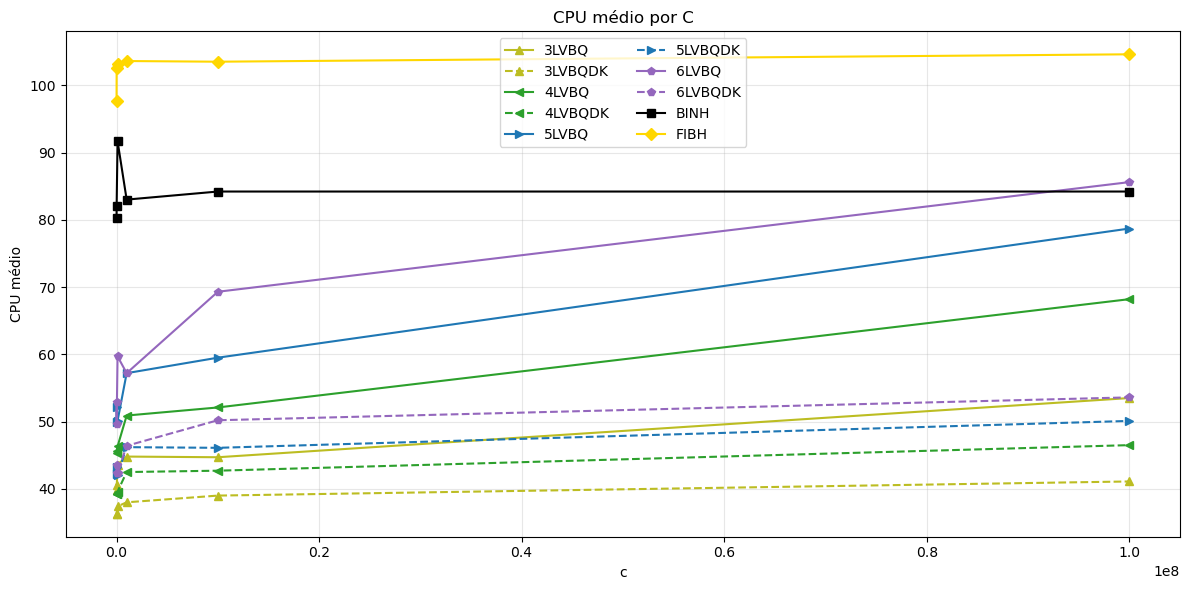

In [174]:
# selecionar BINH, Fibonacci e todas LVBQ (1–6) com ou sem DK
mask = (
    (df_cpu["fila"] == "BINH") |
    (df_cpu["fila"] == "FIBH") |  # adiciona Fibonacci
    (df_cpu["fila"].str.match(r"[1-6]LVBQ(DK)?"))
)

df_sel = df_cpu[mask].copy()

# remover 1 e 2lv
df_sel = df_sel[
    ~(
        df_sel["fila"].str.startswith("2") |
        df_sel["fila"].str.startswith("1")
    )
]

# ordenar por n (ESSENCIAL para gráfico de linhas)
df_sel = df_sel.sort_values("c")

# ordem consistente das curvas
filas_sel = sorted(df_sel["fila"].unique())

# 🔹 marcadores por nível LVBQ
marcadores_nivel = {
    1: "o",   # círculo
    2: "v",   # triângulo para baixo
    3: "^",   # triângulo para cima
    4: "<",   # triângulo para esquerda
    5: ">",   # triângulo para direita
    6: "p",   # pentágono
}

plt.figure(figsize=(12, 6))

for fila in filas_sel:
    dados = df_sel[df_sel["fila"] == fila]

    if dados.empty:
        continue

    # ===== BINH =====
    if fila == "BINH":
        color = "black"
        linestyle = "-"
        marker = "s"

    # ===== FIBH (Fibonacci) =====
    elif fila == "FIBH":
        color = "gold"
        linestyle = "-"
        marker = "D"  # diamante

    # ===== LVBQ / LVBQDK =====
    else:
        nivel = int(re.match(r"\d+", fila).group())

        # 🎨 cor por nível (1–6)
        cores = {
            1: "tab:red",
            2: "tab:orange",
            3: "tab:olive",
            4: "tab:green",
            5: "tab:blue",
            6: "tab:purple",
        }
        color = cores[nivel]

        # DK → tracejado
        linestyle = "--" if "DK" in fila else "-"

        # marcador por nível
        marker = marcadores_nivel[nivel]

    plt.plot(
        dados["c"],
        dados["cpu_mean"],
        label=fila,
        color=color,
        linestyle=linestyle,
        marker=marker
    )

plt.xlabel("c")
plt.ylabel("CPU médio")
plt.title("CPU médio por C")
plt.legend(ncol=2)  # legenda mais compacta
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Outras métricas

In [175]:
df_tcache.head(10)

,nome,n,m,c,insert,extractMin,dk,bkmp,fila,cpu_time,wall_time,l1_miss,l2_ref,llc_miss,cycles,inst,dtlb,page_faults,branch_inst,branch_miss
0,MEM3,100000,500000,1000,144604,144604,0,1978,1LVBQ,34,34,2053886,2575683,86684,146735355,268450551,105278,1066,39023205,249005
1,MEM3,100000,500000,1000,144929,144929,0,1921,1LVBQ,34,34,2065011,2577485,105017,150483151,269203503,103679,0,39189441,245328
2,MEM3,100000,500000,1000,144817,144817,0,1651,1LVBQ,34,34,2065453,2581783,95189,147721831,269149150,105209,536,39172767,248122
3,MEM3,100000,500000,1000,144876,144876,0,1707,1LVBQ,32,32,2064485,2583790,82578,143982845,269111268,103636,0,39181485,246413
4,MEM3,100000,500000,1000,145087,145087,0,2358,1LVBQ,32,32,2076957,2593165,84045,144424498,269375320,109200,0,39216812,245502
5,MEM3,100000,500000,1000,144780,144780,0,2326,1LVBQ,34,34,2074623,2591239,93575,147722336,269179382,106757,518,39181259,249931
6,MEM3,100000,500000,1000,144671,144671,0,2064,1LVBQ,32,32,2060392,2570596,84362,144335479,268980483,104425,0,39167588,245871
7,MEM3,100000,500000,1000,144811,144811,0,1861,1LVBQ,32,32,2080482,2612280,82699,142808552,269196588,108056,0,39198485,245958
8,MEM3,100000,500000,1000,144992,144992,0,1717,1LVBQ,33,33,2067811,2579833,88487,145947563,269537291,105298,517,39234496,248887
9,MEM3,100000,500000,1000,144699,144699,0,1693,1LVBQ,32,32,2068314,2586391,84358,144312299,268930842,105791,0,39159646,246160


In [176]:
df_tcache['ipc'] = df_tcache['inst'] / df_tcache['cycles']

### Eficiência de Cache

In [177]:
# normalizar
df_cache = df_tcache[
    ['nome', 'fila', 'inst', 'l1_miss', 'llc_miss']
].copy()

inst_safe = df_cache["inst"].replace(0, np.nan)

df_cache["l1_pi"]  = df_cache["l1_miss"]  / inst_safe
df_cache["llc_pi"] = df_cache["llc_miss"] / inst_safe


# agregar
df_cache = (
    df_cache.groupby(['nome', 'fila'], as_index=False)
      .agg(
           l1_mean=('l1_pi', 'mean'),
           l1_std =('l1_pi', 'std'),
           l1_var =('l1_pi', 'var'),
           llc_mean=('llc_pi', 'mean'),
           llc_std =('llc_pi', 'std'),
           llc_var =('llc_pi', 'var'),
      )
)

df_cache['l1_cv']  = df_cache['l1_std']  / df_cache['l1_mean']
df_cache['llc_cv'] = df_cache['llc_std'] / df_cache['llc_mean']

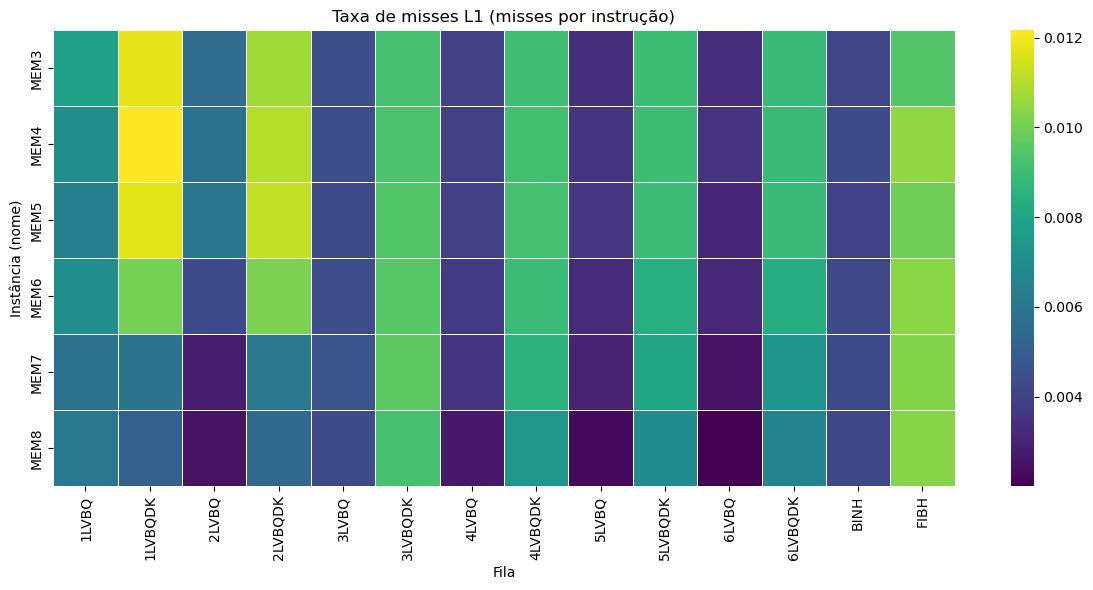

In [178]:

# ===== métrica escolhida =====
df_plot = df_cache.copy()

# opção A: L1 apenas
df_plot["miss"] = df_plot["l1_mean"]

# ===== pivot =====
heat = df_plot.pivot(index="nome", columns="fila", values="miss")
heat = heat.sort_index().sort_index(axis=1)

# ===== plot =====
plt.figure(figsize=(12, 6))

sns.heatmap(
    heat,
    cmap="viridis",
    linewidths=0.5,
    linecolor="white"
)

plt.title("Taxa de misses L1 (misses por instrução)")
plt.xlabel("Fila")
plt.ylabel("Instância (nome)")

plt.tight_layout()
plt.show()

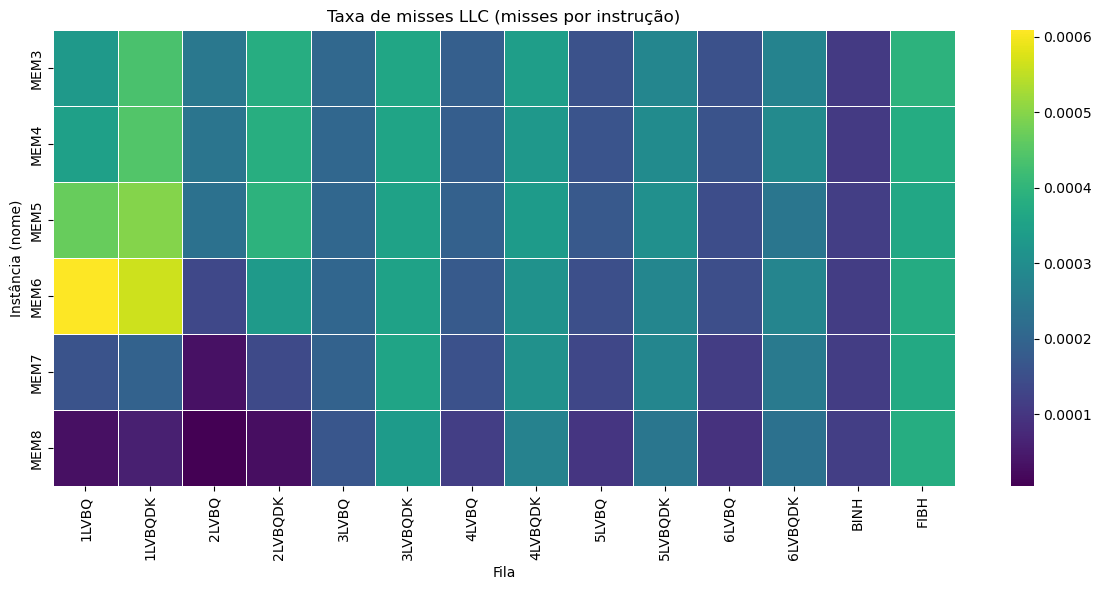

In [179]:

# ===== métrica escolhida =====
df_plot = df_cache.copy()

# opção A: L1 apenas
df_plot["miss"] = df_plot["llc_mean"]

# ===== pivot =====
heat = df_plot.pivot(index="nome", columns="fila", values="miss")
heat = heat.sort_index().sort_index(axis=1)

# ===== plot =====
plt.figure(figsize=(12, 6))

sns.heatmap(
    heat,
    cmap="viridis",
    linewidths=0.5,
    linecolor="white"
)

plt.title("Taxa de misses LLC (misses por instrução)")
plt.xlabel("Fila")
plt.ylabel("Instância (nome)")

plt.tight_layout()
plt.show()

### Instruções e cíclos

In [180]:
df_instc = df_tcache[
    ['nome', 'fila', 'inst', 'cycles']
].copy()

df_instc = (
    df_instc.groupby(['nome', 'fila'], as_index=False)
      .agg(
           inst_total=('inst', 'sum'),
           cycles_total=('cycles', 'sum'),
      )
)

df_instc['ipc'] = (
    df_instc['inst_total'] /
    df_instc['cycles_total'].replace(0, np.nan)
)

df_instc

,nome,fila,inst_total,cycles_total,ipc
0,MEM3,1LVBQ,2691114378,1458473909,1.845158
1,MEM3,1LVBQDK,2148385647,1312215418,1.637220
2,MEM3,2LVBQ,3254383822,1558394486,2.088293
3,MEM3,2LVBQDK,2495340717,1485757632,1.679507
4,MEM3,3LVBQ,4119653657,1813396004,2.271789
...,...,...,...,...,...
79,MEM8,5LVBQDK,4385995321,2218555861,1.976960
80,MEM8,6LVBQ,9961931528,3638281555,2.738087
81,MEM8,6LVBQDK,4672863518,2352416707,1.986410
82,MEM8,BINH,7745640659,3627901124,2.135020


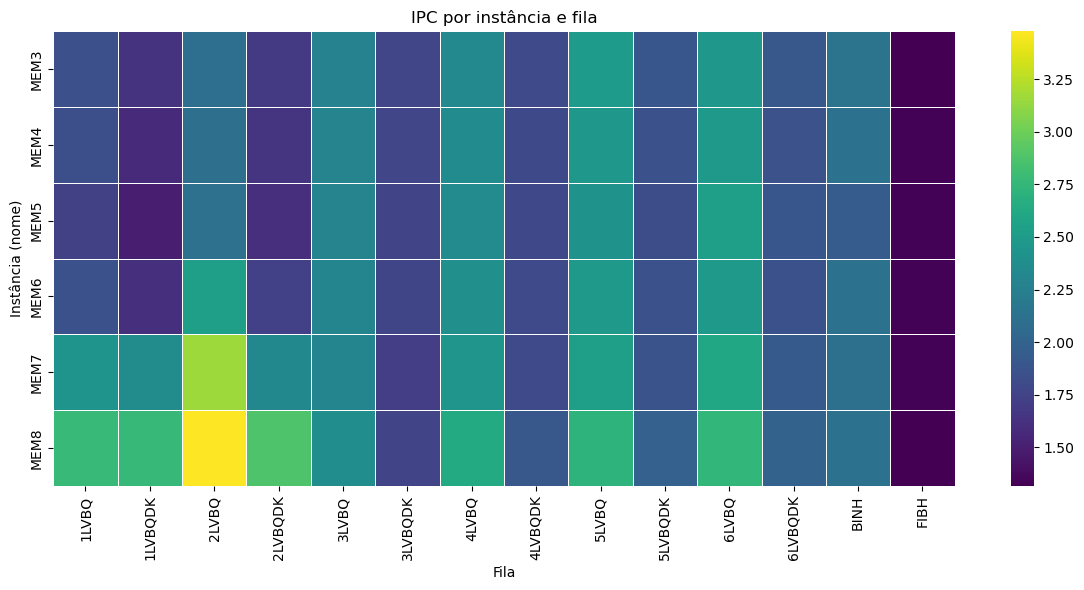

In [181]:

# ===== métrica escolhida =====
df_plot = df_instc.copy()

# opção A: LLC apenas
df_plot["miss"] = df_plot["ipc"]

# ===== pivot =====
heat = df_plot.pivot(index="nome", columns="fila", values="ipc")

# ===== plot =====
plt.figure(figsize=(12, 6))

sns.heatmap(
    heat,
    cmap="viridis",
    linewidths=0.5,
    linecolor="white"
)

plt.title("IPC por instância e fila")
plt.xlabel("Fila")
plt.ylabel("Instância (nome)")

plt.tight_layout()
plt.show()

In [182]:
df_inst = df_tcache[
    ['nome', 'fila', 'inst']
].copy()

df_inst = (
    df_inst.groupby(['nome', 'fila'], as_index=False)
      .agg(
           inst_total=('inst', 'sum'),
           inst_mean=('inst', 'mean'),
           inst_std =('inst', 'std'),
      )
)

df_inst['inst_cv'] = df_inst['inst_std'] / df_inst['inst_mean']
df_inst

,nome,fila,inst_total,inst_mean,inst_std,inst_cv
0,MEM3,1LVBQ,2691114378,269111437.8,2.904566e+05,0.001079
1,MEM3,1LVBQDK,2148385647,214838564.7,9.859157e+04,0.000459
2,MEM3,2LVBQ,3254383822,325438382.2,4.183324e+06,0.012854
3,MEM3,2LVBQDK,2495340717,249534071.7,4.347924e+05,0.001742
4,MEM3,3LVBQ,4119653657,411965365.7,1.776595e+06,0.004312
...,...,...,...,...,...,...
79,MEM8,5LVBQDK,4385995321,438599532.1,1.803105e+05,0.000411
80,MEM8,6LVBQ,9961931528,996193152.8,2.126413e+06,0.002135
81,MEM8,6LVBQDK,4672863518,467286351.8,1.825511e+05,0.000391
82,MEM8,BINH,7745640659,774564065.9,1.158263e+06,0.001495


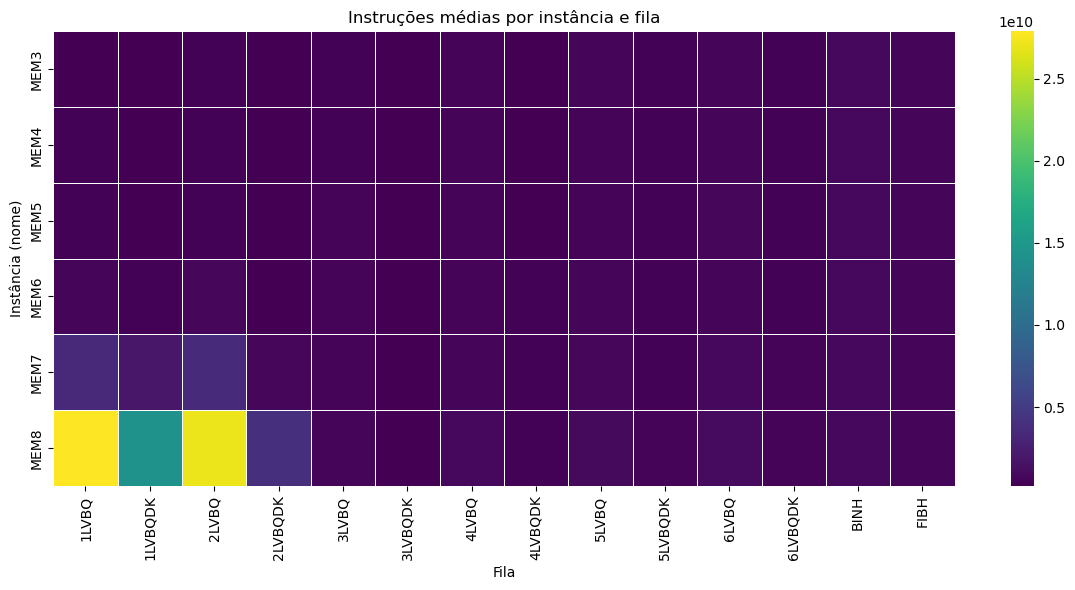

In [183]:

# ===== métrica escolhida =====
df_plot = df_inst.copy()

# opção A: LLC apenas
df_plot["miss"] = df_plot["inst_mean"]

# ===== pivot =====
heat = df_plot.pivot(index="nome", columns="fila", values="inst_mean")

# ===== plot =====
plt.figure(figsize=(12, 6))

sns.heatmap(
    heat,
    cmap="viridis",
    linewidths=0.5,
    linecolor="white"
)

plt.title("Instruções médias por instância e fila")
plt.xlabel("Fila")
plt.ylabel("Instância (nome)")

plt.tight_layout()
plt.show()

### Page fault

In [184]:
# normalizar
df_pf = df_tcache[
    ['nome', 'fila', 'inst', 'page_faults']
].copy()

inst_safe = df_pf["inst"].replace(0, np.nan)

df_pf["pf_pi"] = df_pf["page_faults"] / inst_safe

# agregar
df_pf = (
    df_pf.groupby(['nome', 'fila'], as_index=False)
      .agg(
           pf_mean=('pf_pi', 'mean'),
           pf_std =('pf_pi', 'std'),
           pf_var =('pf_pi', 'var'),
      )
)

df_pf['pf_cv'] = df_pf['pf_std'] / df_pf['pf_mean']
df_pf

,nome,fila,pf_mean,pf_std,pf_var,pf_cv
0,MEM3,1LVBQ,9.804866e-07,1.394553e-06,1.944779e-12,1.422307
1,MEM3,1LVBQDK,2.130559e-07,6.479976e-07,4.199009e-13,3.041444
2,MEM3,2LVBQ,1.722983e-07,4.701041e-07,2.209978e-13,2.728432
3,MEM3,2LVBQDK,2.621537e-07,5.958314e-07,3.550150e-13,2.272832
4,MEM3,3LVBQ,4.438871e-07,5.685431e-07,3.232413e-13,1.280828
...,...,...,...,...,...,...
79,MEM8,5LVBQDK,0.000000e+00,0.000000e+00,0.000000e+00,NaN
80,MEM8,6LVBQ,0.000000e+00,0.000000e+00,0.000000e+00,NaN
81,MEM8,6LVBQDK,0.000000e+00,0.000000e+00,0.000000e+00,NaN
82,MEM8,BINH,0.000000e+00,0.000000e+00,0.000000e+00,NaN


In [185]:
# normalizar
df_dtlb = df_tcache[
    ['nome', 'fila', 'inst', 'dtlb']
].copy()

inst_safe = df_dtlb["inst"].replace(0, np.nan)

df_dtlb["dtlb_pi"] = df_dtlb["dtlb"] / inst_safe

# agregar
df_dtlb = (
    df_dtlb.groupby(['nome', 'fila'], as_index=False)
      .agg(
           dtlb_mean=('dtlb_pi', 'mean'),
           dtlb_std=('dtlb_pi', 'std'),
           dtlb_var=('dtlb_pi', 'var'),
      )
)

df_dtlb['dtlb_cv'] = df_dtlb['dtlb_std'] / df_dtlb['dtlb_mean']
df_dtlb

,nome,fila,dtlb_mean,dtlb_std,dtlb_var,dtlb_cv
0,MEM3,1LVBQ,0.000393,0.000007,4.383766e-11,0.016852
1,MEM3,1LVBQDK,0.000525,0.000004,1.759597e-11,0.007990
2,MEM3,2LVBQ,0.000270,0.000005,2.296922e-11,0.017739
3,MEM3,2LVBQDK,0.000464,0.000009,7.647115e-11,0.018857
4,MEM3,3LVBQ,0.000214,0.000010,9.603517e-11,0.045774
...,...,...,...,...,...,...
79,MEM8,5LVBQDK,0.000288,0.000007,5.002971e-11,0.024580
80,MEM8,6LVBQ,0.000093,0.000001,1.666742e-12,0.013813
81,MEM8,6LVBQDK,0.000267,0.000005,3.023128e-11,0.020593
82,MEM8,BINH,0.000125,0.000002,5.154063e-12,0.018106


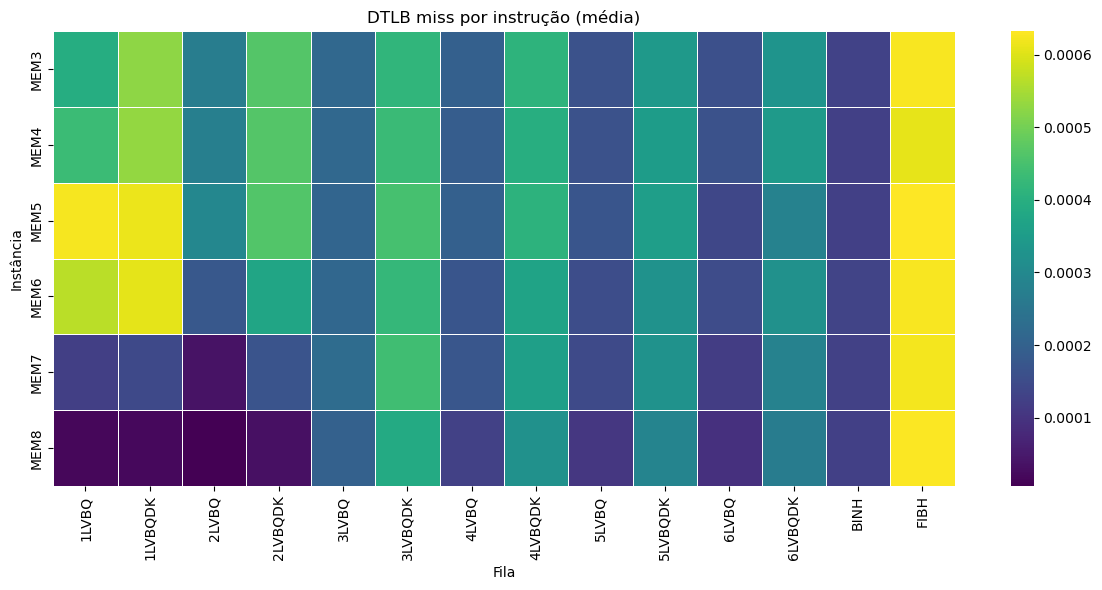

In [186]:
# ===== métrica escolhida =====
df_plot = df_dtlb.copy()

# ===== pivot =====
heat = df_dtlb.pivot(index="nome", columns="fila", values="dtlb_mean")

# ===== plot =====
plt.figure(figsize=(12, 6))

sns.heatmap(
    heat,
    cmap="viridis",
    linewidths=0.5,
    linecolor="white"
)

plt.title("DTLB miss por instrução (média)")
plt.xlabel("Fila")
plt.ylabel("Instância")

plt.tight_layout()
plt.show()

### Branch

In [187]:
# normalizar
df_branches = df_tcache[
    ['nome', 'fila', 'branch_miss', 'branch_inst']
].copy()
inst_safe = df_branches["branch_inst"].replace(0, np.nan)
df_branches['bm_rate'] = df_branches['branch_miss'] / inst_safe

# agregar
df_branches = (
    df_branches.groupby(['nome', 'fila'], as_index=False)
      .agg(
           bm_mean=('bm_rate', 'mean'),
           bm_std =('bm_rate', 'std'),
           bm_var =('bm_rate', 'var'),
      )
)
df_branches['bm_cv'] = df_branches['bm_std'] / df_branches['bm_mean']
df_branches

,nome,fila,bm_mean,bm_std,bm_var,bm_cv
0,MEM3,1LVBQ,0.006308,0.000047,2.195555e-09,0.007428
1,MEM3,1LVBQDK,0.008503,0.000053,2.788634e-09,0.006211
2,MEM3,2LVBQ,0.004848,0.000020,4.044416e-10,0.004149
3,MEM3,2LVBQDK,0.007938,0.000013,1.700224e-10,0.001643
4,MEM3,3LVBQ,0.004631,0.000188,3.538403e-08,0.040621
...,...,...,...,...,...,...
79,MEM8,5LVBQDK,0.012201,0.000052,2.691942e-09,0.004253
80,MEM8,6LVBQ,0.004502,0.000032,1.022227e-09,0.007101
81,MEM8,6LVBQDK,0.013673,0.000061,3.661689e-09,0.004426
82,MEM8,BINH,0.016211,0.000016,2.575396e-10,0.000990


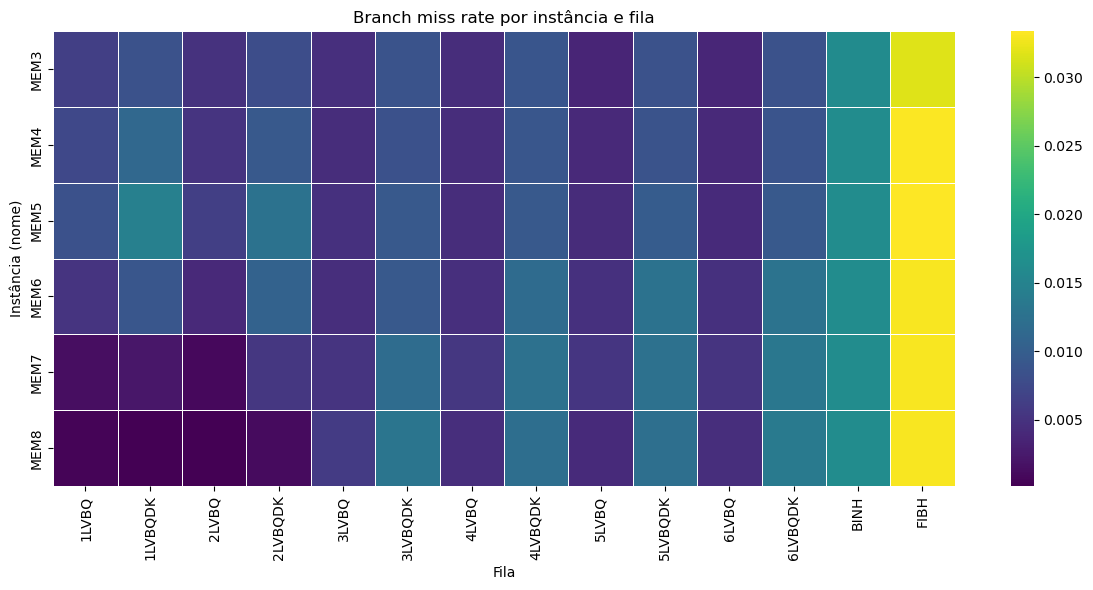

In [188]:

# ===== métrica escolhida =====
df_plot = df_branches.copy()

# opção A: LLC apenas
df_plot["miss"] = df_plot["bm_mean"]

# ===== pivot =====
heat = df_plot.pivot(index="nome", columns="fila", values="bm_mean")

# ===== plot =====
plt.figure(figsize=(12, 6))

sns.heatmap(
    heat,
    cmap="viridis",
    linewidths=0.5,
    linecolor="white"
)

plt.title("Branch miss rate por instância e fila")
plt.xlabel("Fila")
plt.ylabel("Instância (nome)")

plt.tight_layout()
plt.show()

In [189]:
df_inst = df_tcache[
    ['nome', 'n', 'c', 'fila', 'inst']
].copy()
df_inst = (
    df_inst.groupby(['nome', 'fila'], as_index=False)
      .agg(
           inst_mean=('inst', 'mean'),
           inst_std =('inst', 'std'),
           inst_var =('inst', 'var'),
           c=('c', 'first'),
      )
)
df_inst['inst_cv'] = df_inst['inst_std'] / df_inst['inst_mean']
df_inst

,nome,fila,inst_mean,inst_std,inst_var,c,inst_cv
0,MEM3,1LVBQ,269111437.8,2.904566e+05,8.436504e+10,1000,0.001079
1,MEM3,1LVBQDK,214838564.7,9.859157e+04,9.720299e+09,1000,0.000459
2,MEM3,2LVBQ,325438382.2,4.183324e+06,1.750020e+13,1000,0.012854
3,MEM3,2LVBQDK,249534071.7,4.347924e+05,1.890444e+11,1000,0.001742
4,MEM3,3LVBQ,411965365.7,1.776595e+06,3.156289e+12,1000,0.004312
...,...,...,...,...,...,...,...
79,MEM8,5LVBQDK,438599532.1,1.803105e+05,3.251186e+10,99999791,0.000411
80,MEM8,6LVBQ,996193152.8,2.126413e+06,4.521634e+12,99999791,0.002135
81,MEM8,6LVBQDK,467286351.8,1.825511e+05,3.332491e+10,99999791,0.000391
82,MEM8,BINH,774564065.9,1.158263e+06,1.341574e+12,99999791,0.001495


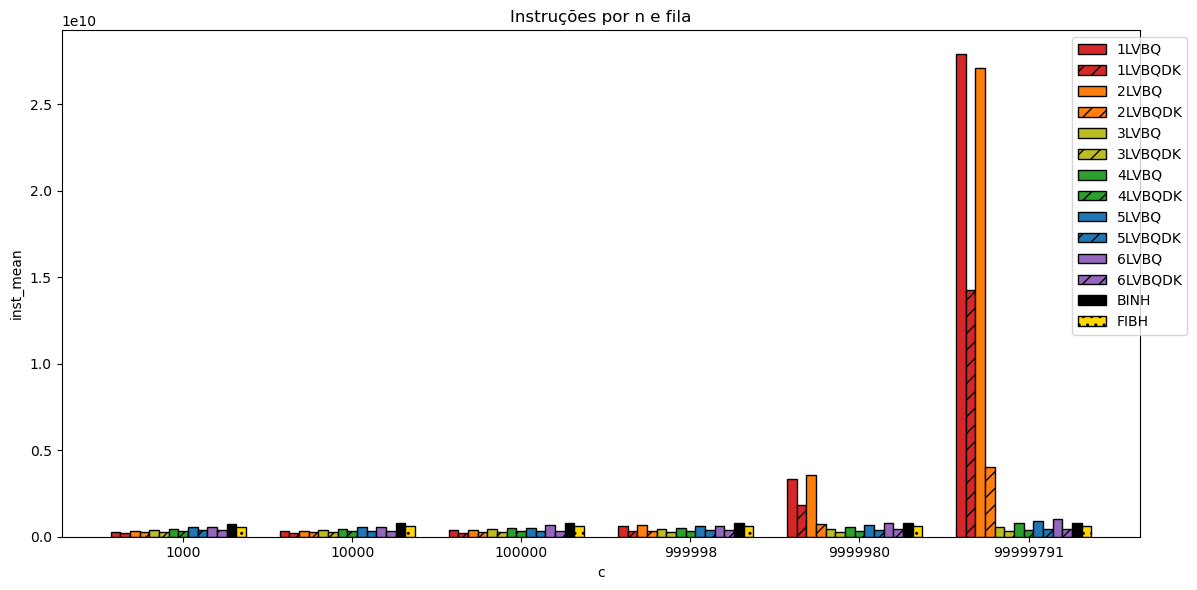

In [190]:
pivot = df_inst.pivot_table(
    index="c",
    columns="fila",
    values="inst_mean", 
    aggfunc="first"
)

n_vals = pivot.index.to_list()
filas = pivot.columns.to_list()

x = np.arange(len(n_vals))
width = 0.8 / len(filas)

# 🎨 cores por número da fila (LVBQ)
colors = {
    "1": "tab:red",
    "2": "tab:orange",
    "3": "tab:olive",
    "4": "tab:green",
    "5": "tab:blue",
    "6": "tab:purple",
}

plt.figure(figsize=(12, 6))

for i, fila in enumerate(filas):

    # ===== HEAPS (se existirem) =====
    if "BINH" in fila:
        color = "black"
        hatch = "xx"
        
    elif "FIBH" in fila:
        color = "gold"
        hatch = ".."

    # ===== LVBQ / LVBQDK =====
    else:
        m = re.match(r"\d+", fila)
        num = m.group() if m else None

        color = colors.get(num, "tab:gray")

        # DK com padrão
        hatch = "//" if "LVBQDK" in fila else None

    plt.bar(
        x + i * width,
        pivot[fila].values,
        width,
        label=fila,
        color=color,
        hatch=hatch,
        edgecolor="black"
    )

plt.xticks(x + width * len(filas) / 2, n_vals)
plt.xlabel("c")
plt.ylabel("inst_mean")  # 👈 eixo Y atualizado
plt.title("Instruções por n e fila")
plt.legend(bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()

# Cache miss

In [191]:
df_cache = df_tcache[
    ['nome', 'n', 'c', 'fila', 'l1_miss']
].copy()
df_cache = (
    df_cache.groupby(['nome', 'fila'], as_index=False)
      .agg(
           l1_mean=('l1_miss', 'mean'),
           l1_std =('l1_miss', 'std'),
           l1_var =('l1_miss', 'var'),
           c=('c', 'first'),
      )
)
df_cache['l1_cv'] = df_cache['l1_std'] / df_cache['l1_mean']
df_cache

,nome,fila,l1_mean,l1_std,l1_var,c,l1_cv
0,MEM3,1LVBQ,2067741.4,7917.779532,6.269123e+07,1000,0.003829
1,MEM3,1LVBQDK,2527205.9,7205.776563,5.192322e+07,1000,0.002851
2,MEM3,2LVBQ,1811037.1,20252.694600,4.101716e+08,1000,0.011183
3,MEM3,2LVBQDK,2677933.3,12717.063288,1.617237e+08,1000,0.004749
4,MEM3,3LVBQ,1812748.3,10948.621669,1.198723e+08,1000,0.006040
...,...,...,...,...,...,...,...
79,MEM8,5LVBQDK,3020270.6,6976.728065,4.867473e+07,99999791,0.002310
80,MEM8,6LVBQ,2004189.4,11212.013053,1.257092e+08,99999791,0.005594
81,MEM8,6LVBQDK,3061267.1,7289.609080,5.313840e+07,99999791,0.002381
82,MEM8,BINH,3234176.6,123351.564458,1.521561e+10,99999791,0.038140


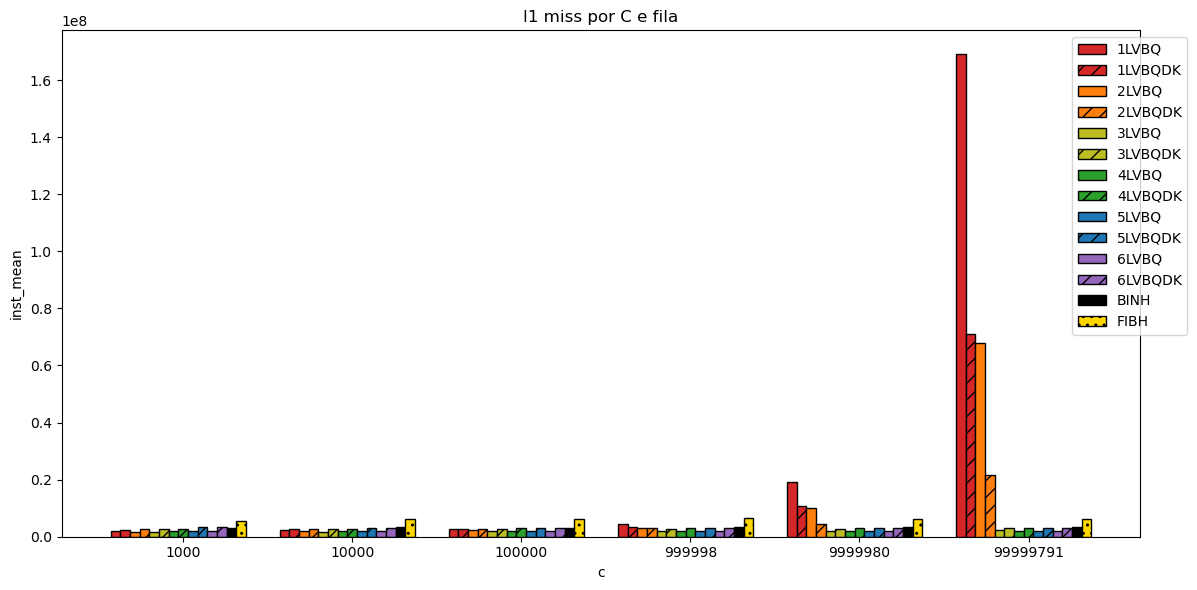

In [192]:
pivot = df_cache.pivot_table(
    index="c",
    columns="fila",
    values="l1_mean",
    aggfunc="first"
)

n_vals = pivot.index.to_list()
filas = pivot.columns.to_list()

x = np.arange(len(n_vals))
width = 0.8 / len(filas)

# 🎨 cores por número da fila (LVBQ)
colors = {
    "1": "tab:red",
    "2": "tab:orange",
    "3": "tab:olive",
    "4": "tab:green",
    "5": "tab:blue",
    "6": "tab:purple",
}

plt.figure(figsize=(12, 6))

for i, fila in enumerate(filas):

    # ===== HEAPS (se existirem) =====
    if "BINH" in fila:
        color = "black"
        hatch = "xx"
        
    elif "FIBH" in fila:
        color = "gold"
        hatch = ".."

    # ===== LVBQ / LVBQDK =====
    else:
        m = re.match(r"\d+", fila)
        num = m.group() if m else None

        color = colors.get(num, "tab:gray")

        # DK com padrão
        hatch = "//" if "LVBQDK" in fila else None

    plt.bar(
        x + i * width,
        pivot[fila].values,
        width,
        label=fila,
        color=color,
        hatch=hatch,
        edgecolor="black"
    )

plt.xticks(x + width * len(filas) / 2, n_vals)
plt.xlabel("c")
plt.ylabel("inst_mean")
plt.title("l1 miss por C e fila")
plt.legend(bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()

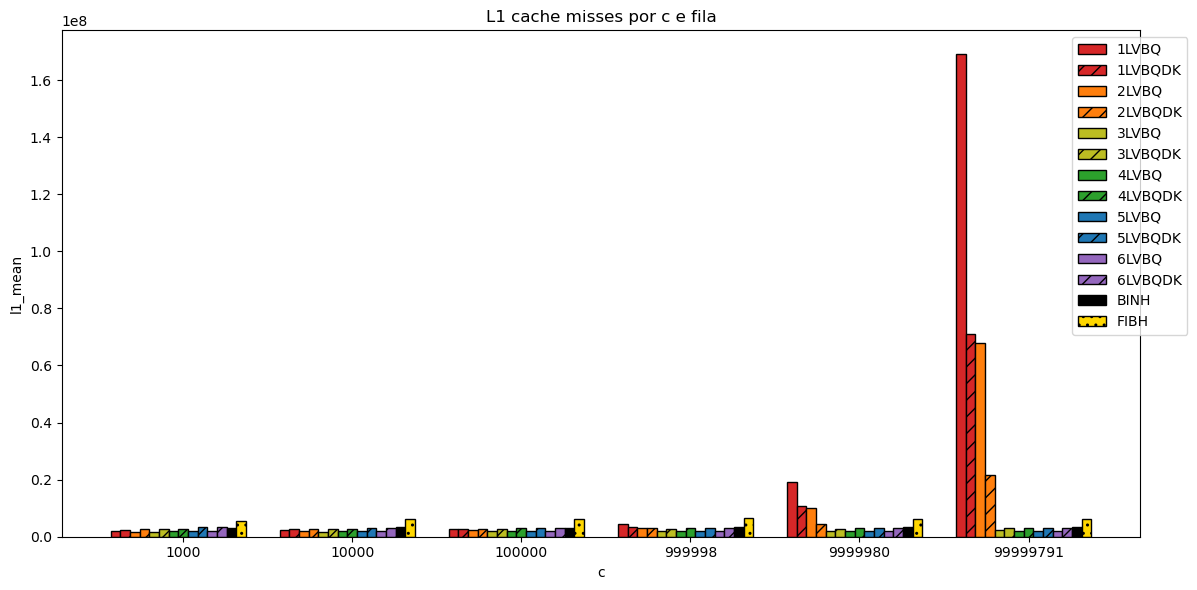

In [193]:
pivot = df_cache.pivot_table(
    index="c",
    columns="fila",
    values="l1_mean",
    aggfunc="first"
)

n_vals = pivot.index.to_list()
filas = pivot.columns.to_list()

x = np.arange(len(n_vals))
width = 0.8 / len(filas)

# 🎨 cores por número da fila (LVBQ)
colors = {
    "1": "tab:red",
    "2": "tab:orange",
    "3": "tab:olive",
    "4": "tab:green",
    "5": "tab:blue",
    "6": "tab:purple",
}

plt.figure(figsize=(12, 6))

for i, fila in enumerate(filas):

    # ===== HEAPS (se existirem) =====
    if "BINH" in fila:
        color = "black"
        hatch = "xx"
        
    elif "FIBH" in fila:
        color = "gold"
        hatch = ".."

    # ===== LVBQ / LVBQDK =====
    else:
        m = re.match(r"\d+", fila)
        num = m.group() if m else None

        color = colors.get(num, "tab:gray")

        # DK com padrão
        hatch = "//" if "LVBQDK" in fila else None

    plt.bar(
        x + i * width,
        pivot[fila].values,
        width,
        label=fila,
        color=color,
        hatch=hatch,
        edgecolor="black"
    )

plt.xticks(x + width * len(filas) / 2, n_vals)
plt.xlabel("c")
plt.ylabel("l1_mean")
plt.title("L1 cache misses por c e fila")
plt.legend(bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()

In [194]:
df_cache = df_tcache[
    ['nome', 'n', 'c', 'fila', 'llc_miss']
].copy()
df_cache = (
    df_cache.groupby(['nome', 'fila'], as_index=False)
      .agg(
           llc_mean=('llc_miss', 'mean'),
           llc_std =('llc_miss', 'std'),
           llc_var =('llc_miss', 'var'),
           c=('c', 'first'),
      )
)
df_cache['llc_cv'] = df_cache['llc_std'] / df_cache['llc_mean']
df_cache

,nome,fila,llc_mean,llc_std,llc_var,c,llc_cv
0,MEM3,1LVBQ,88699.4,7219.248764,5.211755e+07,1000,0.081390
1,MEM3,1LVBQDK,93706.1,1650.419438,2.723884e+06,1000,0.017613
2,MEM3,2LVBQ,80526.3,5121.977245,2.623465e+07,1000,0.063606
3,MEM3,2LVBQDK,95285.4,1817.983877,3.305065e+06,1000,0.019079
4,MEM3,3LVBQ,85454.9,2182.104664,4.761581e+06,1000,0.025535
...,...,...,...,...,...,...,...
79,MEM8,5LVBQDK,106280.0,2242.607857,5.029290e+06,99999791,0.021101
80,MEM8,6LVBQ,91300.3,5101.439275,2.602468e+07,99999791,0.055875
81,MEM8,6LVBQDK,107091.5,2714.679079,7.369482e+06,99999791,0.025349
82,MEM8,BINH,88236.5,1309.148769,1.713870e+06,99999791,0.014837


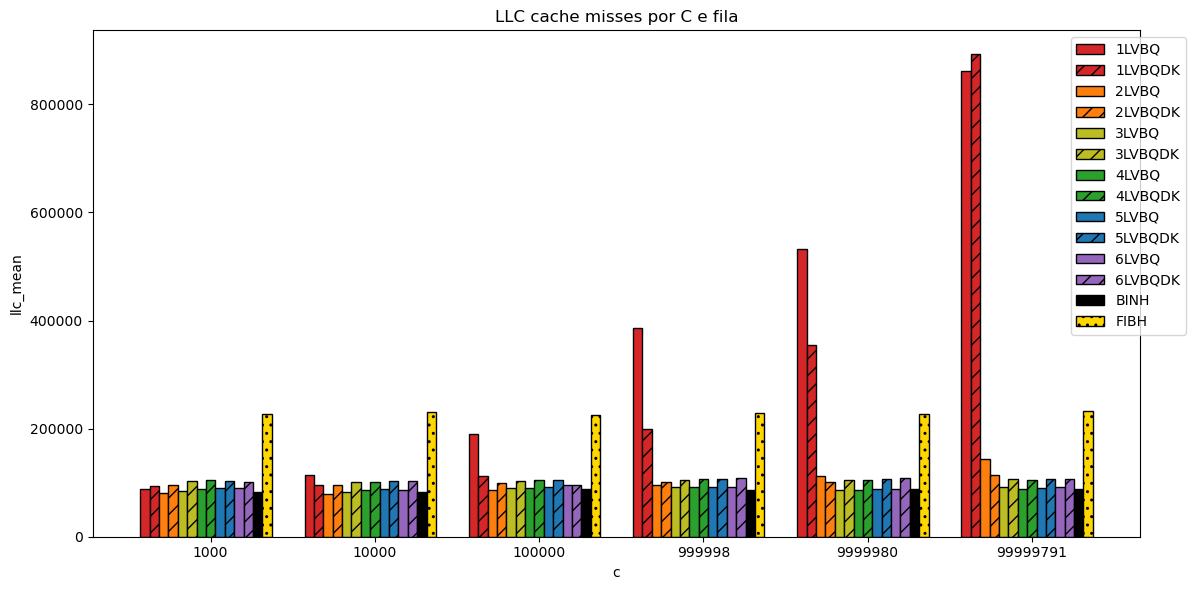

In [195]:
pivot = df_cache.pivot_table(
    index="c",
    columns="fila",
    values="llc_mean",
    aggfunc="first"
)

n_vals = pivot.index.to_list()
filas = pivot.columns.to_list()

x = np.arange(len(n_vals))
width = 0.8 / len(filas)

# 🎨 cores por número da fila (LVBQ)
colors = {
    "1": "tab:red",
    "2": "tab:orange",
    "3": "tab:olive",
    "4": "tab:green",
    "5": "tab:blue",
    "6": "tab:purple",
}

plt.figure(figsize=(12, 6))

for i, fila in enumerate(filas):

    # ===== HEAPS (se existirem) =====
    if "BINH" in fila:
        color = "black"
        hatch = "xx"
        
    elif "FIBH" in fila:
        color = "gold"
        hatch = ".."

    # ===== LVBQ / LVBQDK =====
    else:
        m = re.match(r"\d+", fila)
        num = m.group() if m else None

        color = colors.get(num, "tab:gray")

        # DK com padrão
        hatch = "//" if "LVBQDK" in fila else None

    plt.bar(
        x + i * width,
        pivot[fila].values,
        width,
        label=fila,
        color=color,
        hatch=hatch,
        edgecolor="black"
    )

plt.xticks(x + width * len(filas) / 2, n_vals)
plt.xlabel("c")
plt.ylabel("llc_mean")
plt.title("LLC cache misses por C e fila")
plt.legend(bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()